In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

vipoooool_new_plant_diseases_dataset_path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')
mohamedabdelaziz05_test_12345_path = kagglehub.dataset_download('mohamedabdelaziz05/test-12345')

print('Data source import complete.')


In [ ]:
import os

dataset_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset"

print(os.listdir(dataset_path))

['New Plant Diseases Dataset(Augmented)', 'new plant diseases dataset(augmented)', 'test']


In [ ]:
train_path="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_path="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
test_path="/kaggle/input/datasets/rashidthihan/plant-disease-dataset/plant_disease_dataset/test"


In [ ]:
train_dir = train_path
val_dir = valid_path
test_dir = test_path

In [ ]:
import os

print("Train ->", len(os.listdir(train_dir)))
print("Valid ->", len(os.listdir(val_dir)))


Train -> 38
Valid -> 38


In [ ]:
import os

train_classes = sorted(os.listdir(train_dir))
valid_classes = sorted(os.listdir(val_dir))

print(train_classes == valid_classes)

True


In [ ]:
classes = os.listdir(train_dir)
print("num of classes", len(classes))
print(classes[:10])
#The dataset has 38 classes of plant diseases and healthy plants

num of classes 38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


In [ ]:
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        path = os.path.join(folder, cls)
        if os.path.isdir(path):
            counts[cls] = len(os.listdir(path))
    return counts

train_counts = count_images(train_dir)
train_counts
#The dataset is well balanced across all 38 classes

{'Tomato___Late_blight': 1851,
 'Tomato___healthy': 1926,
 'Grape___healthy': 1692,
 'Orange___Haunglongbing_(Citrus_greening)': 2010,
 'Soybean___healthy': 2022,
 'Squash___Powdery_mildew': 1736,
 'Potato___healthy': 1824,
 'Corn_(maize)___Northern_Leaf_Blight': 1908,
 'Tomato___Early_blight': 1920,
 'Tomato___Septoria_leaf_spot': 1745,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 1642,
 'Strawberry___Leaf_scorch': 1774,
 'Peach___healthy': 1728,
 'Apple___Apple_scab': 2016,
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 1961,
 'Tomato___Bacterial_spot': 1702,
 'Apple___Black_rot': 1987,
 'Blueberry___healthy': 1816,
 'Cherry_(including_sour)___Powdery_mildew': 1683,
 'Peach___Bacterial_spot': 1838,
 'Apple___Cedar_apple_rust': 1760,
 'Tomato___Target_Spot': 1827,
 'Pepper,_bell___healthy': 1988,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 1722,
 'Potato___Late_blight': 1939,
 'Tomato___Tomato_mosaic_virus': 1790,
 'Strawberry___healthy': 1824,
 'Apple___healthy': 2008,
 'Gra

In [ ]:
classes = os.listdir(train_dir)
print("Num of classes", len(classes))
print(classes[:10])

Num of classes 38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


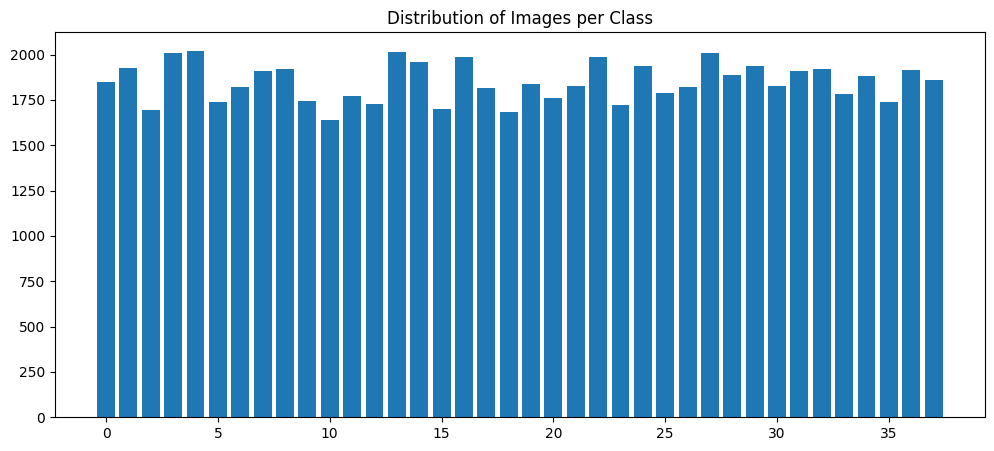

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(range(len(train_counts)), list(train_counts.values()))
plt.title("Distribution of Images per Class")
plt.show()
#The bar chart shows that the dataset is well balanced across all 38 classes

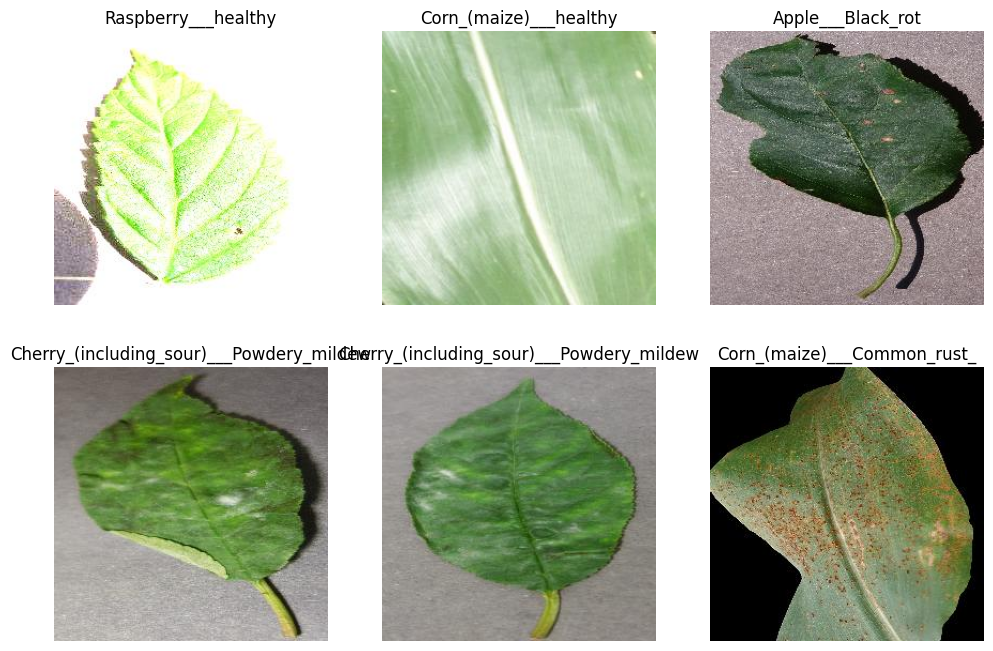

In [ ]:
from PIL import Image
import random

plt.figure(figsize=(12,8))

for i in range(6):
    cls = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(train_dir, cls)))
    img_path = os.path.join(train_dir, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()
#The dataset contains clear and good-quality images from different classes

In [ ]:
sizes = []

for cls in classes[:5]:  # sample
    for img_name in os.listdir(os.path.join(train_dir, cls))[:50]:
        img_path = os.path.join(train_dir, cls, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

sizes[:10]
#All images in the dataset have a uniform size of 256×256 pixels

[(256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256)]

In [ ]:
img = Image.open(img_path)
import numpy as np

img_array = np.array(img)
print(img_array.shape)
#The images are RGB with shape 256×256×3

(256, 256, 3)


In [ ]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),  # يساعد مع اختلاف الإضاءة
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root=train_dir,transform=train_transform)

valid_dataset = datasets.ImageFolder(root=val_dir,transform=val_test_transform)

print(train_dataset)
print(valid_dataset)

Dataset ImageFolder
    Number of datapoints: 70295
    Root location: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.6, 1.4), contrast=(0.6, 1.4), saturation=(0.7, 1.3), hue=None)
               RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Dataset ImageFolder
    Number of datapoints: 17572
    Root location: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
    StandardTransform
Transform: Compose(
               Resize(size=(224,

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
print("Train Images:", len(train_dataset))
print("Validation Images:", len(valid_dataset))
print("Classes:", train_dataset.classes)
print("Number of Classes:", len(train_dataset.classes))

Train Images: 70295
Validation Images: 17572
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spid

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([128, 3, 224, 224])
torch.Size([128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


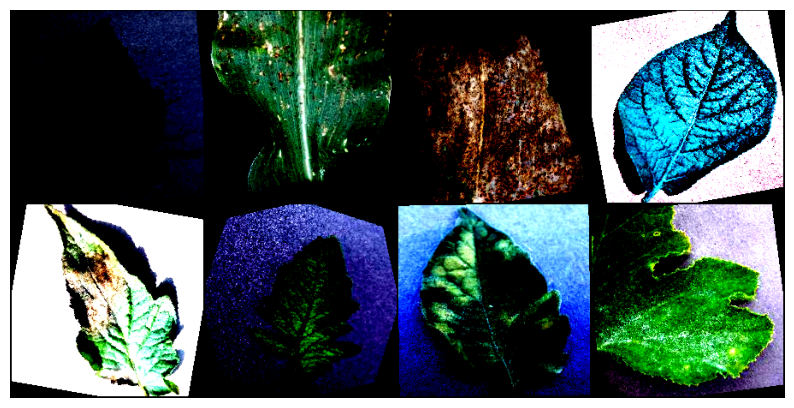

In [ ]:
import matplotlib.pyplot as plt
import torchvision

images, labels = next(iter(train_loader))

grid = torchvision.utils.make_grid(images[:8], nrow=4)

plt.figure(figsize=(10,6))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from torchvision import models

weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s] 


In [ ]:
classes = os.listdir(train_dir)
print("num of classes", len(classes))
print(classes[:10])
#The dataset has 38 classes of plant diseases and healthy plants

num of classes 38
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
"""
model.py
Builds the ResNet50 model with a custom classification head.
"""
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 38

def build_model(num_classes=NUM_CLASSES):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(num_classes=38).to(device)
print(model)
print("Device:", device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
from tqdm.notebook import tqdm
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=10, model_name="model", device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    best_val_acc = 0.0
    scaler = torch.cuda.amp.GradScaler()
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)
        # ===================== TRAIN =====================
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += (preds == labels).sum().item()
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects / len(train_loader.dataset)
        # ===================== VALIDATION =====================
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc="Validation"):
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += (preds == labels).sum().item()
        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = val_running_corrects / len(val_loader.dataset)
        # ===================== LOG =====================
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)
        print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
        print(f"Val   Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")
        # ===================== SAVE BEST =====================
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            print(f"✓ Best model saved! Acc: {best_val_acc:.4f}")
    print(f"\n🔥 Best Val Acc: {best_val_acc:.4f}")
    return history

In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # ← اتغيرت من 1e-3

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    model_name="resnet50_plant_38class"
)


Epoch 1/10
----------------------------------------


/tmp/ipykernel_58/330746876.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Training:   0%|          | 0/550 [00:00<?, ?it/s]

/tmp/ipykernel_58/330746876.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validation:   0%|          | 0/138 [00:00<?, ?it/s]

...

Training:   0%|          | 0/550 [00:00<?, ?it/s]

Validation:   0%|          | 0/138 [00:00<?, ?it/s]

Train Loss: 0.0210 | Train Acc: 0.9938
Val   Loss: 0.0144 | Val Acc: 0.9955
✓ Best model saved! Acc: 0.9955

Epoch 4/10
----------------------------------------


Training:   0%|          | 0/550 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import os
print(os.path.exists("resnet50_plant_38class_best.pth"))
print(os.path.getsize("resnet50_plant_38class_best.pth"))  # الحجم بالبايت، للتأكيد إنه اتحفظ فعلاً

True
94668151


In [ ]:
from PIL import Image
import torch

In [ ]:
classes = train_dataset.classes
print(classes)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [ ]:
from torchvision import transforms
image_path = "/kaggle/input/datasets/mohamedabdelaziz05/test-12345/Frogeye-spots-Botryosphaeria-obtusa-on-apple-leaf-FB.jpg"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)

model.eval()  # ← السطر الجديد المهم

with torch.no_grad():
    outputs = model(image_tensor)
    probs = torch.softmax(outputs, dim=1)
    topk = torch.topk(probs, 5)

    for i in range(5):
        class_name = classes[topk.indices[0][i].item()]
        confidence = topk.values[0][i].item() * 100
        print(class_name, confidence)

Apple___Black_rot 97.49999642372131
Peach___Bacterial_spot 0.47540911473333836
Apple___Apple_scab 0.4487572703510523
Apple___Cedar_apple_rust 0.3686892567202449
Grape___Black_rot 0.3608700819313526
